# 2. Quantile delta mapping of CMIP6 forcing

This notebook applies **monthly quantile delta mapping (QDM)** to historical CMIP6 forcing.

For now, the target period is also historical CMIP6 **1995–2014**. This is useful for testing whether bias-corrected CMIP6 forcing improves the HBV discharge output.

Inputs:

- ERA5 forcing 1995–2014 = reference
- CMIP6 historical forcing 1995–2014 = historical model
- CMIP6 historical forcing 1995–2014 = target model for testing

Output:

- Corrected CMIP6 forcing folder: `CMIP6-QDM-historical-1995-2014`

## 1. Startup

In [108]:
# pip install python-cmethods

In [109]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import xarray as xr
import yaml
from cmethods import adjust
import matplotlib.pyplot as plt


from rich import print

In [110]:
import ewatercycle
import ewatercycle.forcing

In [111]:
start_year = 1995
end_year = 2014

Scenario = "historical"

In [112]:
# Defining paths

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / f"ERA5-{start_year}-{end_year}"

forcing_path_CMIP = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "CMIP6" / "historical" / f"CMIP6-{start_year}-{end_year}"

forcing_path_CMIP_target = forcing_path_CMIP
forcing_path_CMIP_hist = forcing_path_CMIP

forcing_path_QDM = Path.home() / "BEP-maxime" / "Workyard" / "forcings" / "CMIP6" / "historical" / f"CMIP6-QDM-{start_year}-{end_year}"
forcing_path_QDM.mkdir(parents=True, exist_ok=True)

shape_file = Path.home() / "BEP-maxime" / "Workyard" / "Shapefiles" / "07DA001_basin.shp"

var_names = ["pr", "tas", "rsds", "evspsblpot"]

print(forcing_path_ERA5)
print(forcing_path_CMIP_hist)
print(forcing_path_QDM)

/home/maxime/BEP-maxime/Workyard/forcings/ERA5-1995-2014

/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-1995-2014

/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014

## 2. Helper functions for loading forcing variables

In [113]:
def find_file_for_var(folder, var_name):

    folder = Path(folder)

    # First try exact final variable pattern, then broader search
    matches = list(folder.glob(f"*_{var_name}.nc"))

    if len(matches) == 0:
        matches = list(folder.glob(f"*{var_name}*.nc"))

    if len(matches) == 0:
        raise FileNotFoundError(f"No NetCDF file found for {var_name} in {folder}")

    if len(matches) > 1:
        print(f"Multiple files found for {var_name}, using first:")
        for match in matches:
            print(" -", match.name)

    return matches[0]


def get_dataarray(dataset, preferred_name):

    if preferred_name in dataset.data_vars:
        return dataset[preferred_name]

    first_var = list(dataset.data_vars)[0]
    print(f"Variable {preferred_name} not found, using {first_var} instead.")
    return dataset[first_var]


def load_variable(folder, var_name):

    file_path = find_file_for_var(folder, var_name)

    ds = xr.open_dataset(file_path)
    da = get_dataarray(ds, var_name).squeeze()
    
        # Normalize daily time coordinate: removes 11:30 / 12:00 differences
    da = da.assign_coords(time=pd.to_datetime(da.time.values).normalize())

    if "time" not in da.dims:
        raise ValueError(f"{file_path} does not contain a time dimension.")

    return da, ds, file_path


def check_variable_shapes():

    for var_name in var_names:

        era5_da, _, era5_file = load_variable(forcing_path_ERA5, var_name)
        cmip_da, _, cmip_file = load_variable(forcing_path_CMIP_hist, var_name)

        print("\n", var_name)
        print("ERA5:", era5_da.shape, era5_da.dims, era5_file.name)
        print("CMIP:", cmip_da.shape, cmip_da.dims, cmip_file.name)
        print("ERA5 units:", era5_da.attrs.get("units"))
        print("CMIP units:", cmip_da.attrs.get("units"))


In [114]:
check_variable_shapes()


pr

ERA5:
(7305,)
('time',)
combined_ERA5_1995_2014_pr.nc

CMIP:
(7305,)
('time',)
combined_CMIP6_1995_2014_pr.nc

ERA5 units: kg m-2 s-1

CMIP units: kg m-2 s-1

...

evspsblpot

ERA5:
(7305,)
('time',)
combined_ERA5_1995_2014_evspsblpot.nc

CMIP:
(7305,)
('time',)
combined_CMIP6_1995_2014_evspsblpot.nc

ERA5 units: kg m-2 s-1

CMIP units: kg m-2 s-1

## 4. Bias-correction settings

For this version, the correction is done with `cmethods.adjust(method="quantile_delta_mapping")`.

- `tas`: additive correction (`kind="+"`)
- `pr`, `rsds`, `evspsblpot`: multiplicative correction (`kind="*"`)
- Negative corrected values are removed for non-temperature variables.


In [115]:
method = "quantile_delta_mapping"
n_quantiles = 250

def correction_kind(var_name):
    if var_name == "tas":
        return "+"
    else:
        return "*"


In [116]:
def monthly_qdm(obs_da, simh_da, simp_da, var_name):

    corrected_months = []

    kind = correction_kind(var_name)

    for month in range(1, 13):

        obs_m = obs_da.sel(time=obs_da.time.dt.month == month)
        simh_m = simh_da.sel(time=simh_da.time.dt.month == month)
        simp_m = simp_da.sel(time=simp_da.time.dt.month == month)

        # Save original target time
        simp_time = simp_m.time

        # Reset time index so cmethods does not require exact same dates
        obs_m = obs_m.assign_coords(time=np.arange(len(obs_m.time)))
        simh_m = simh_m.assign_coords(time=np.arange(len(simh_m.time)))
        simp_m = simp_m.assign_coords(time=np.arange(len(simp_m.time)))

        corrected_m = adjust(
            method=method,
            obs=obs_m.astype("float64"),
            simh=simh_m.astype("float64"),
            simp=simp_m.astype("float64"),
            n_quantiles=n_quantiles,
            kind=kind,
        )

        if isinstance(corrected_m, xr.Dataset):
            corrected_m = corrected_m[var_name]

        # Put original dates back
        corrected_m = corrected_m.assign_coords(time=simp_time)

        corrected_months.append(corrected_m)

    corrected_da = xr.concat(corrected_months, dim="time")
    corrected_da = corrected_da.sortby("time")

    corrected_da.name = var_name

    if var_name != "tas":
        corrected_da = corrected_da.clip(min=0)

    return corrected_da.astype("float32")

In [117]:
def derive_monthly_pr_thresholds(reference_pr, corrected_pr, dry_threshold_mm_day=0.1):

    thresholds = {}

    ref = to_series(reference_pr) * 86400
    qdm = to_series(corrected_pr) * 86400

    for month in range(1, 13):

        ref_m = ref[ref.index.month == month]
        qdm_m = qdm[qdm.index.month == month]

        # Fraction of dry days in ERA5
        dry_fraction = (ref_m < dry_threshold_mm_day).mean()

        # QDM precipitation threshold giving same dry-day fraction
        qdm_threshold_mm_day = qdm_m.quantile(dry_fraction)

        # Convert back to kg m-2 s-1
        thresholds[month] = qdm_threshold_mm_day / 86400

    return thresholds


def apply_monthly_pr_thresholds(pr_da, thresholds):

    pr_new = pr_da.copy()

    for month in range(1, 13):

        month_mask = pr_new.time.dt.month == month
        threshold = thresholds[month]

        pr_new = pr_new.where(
            ~(month_mask & (pr_new < threshold)),
            0
        )

    return pr_new

## 5. Apply bias correction and save NetCDF files

In [118]:
def bias_correct_variable(var_name):

    print(f"\nCorrecting {var_name}")

    # ERA5 = observed/reference historical period
    obs_da, obs_ds, obs_file = load_variable(forcing_path_ERA5, var_name)

    # CMIP historical = model historical/control period
    simh_da, simh_ds, simh_file = load_variable(forcing_path_CMIP, var_name)

    # CMIP target = data to correct
    simp_da, simp_ds, simp_file = load_variable(forcing_path_CMIP_target, var_name)

    # cmethods works with xarray DataArray objects with a time dimension
    corrected_da = monthly_qdm(
        obs_da=obs_da,
        simh_da=simh_da,
        simp_da=simp_da,
        var_name=var_name
    )

    # Additional dry-day correction for precipitation
    if var_name == "pr":

        thresholds = derive_monthly_pr_thresholds(
            reference_pr=obs_da,
            corrected_pr=corrected_da,
            dry_threshold_mm_day=0.1
        )
    
        corrected_da = apply_monthly_pr_thresholds(
            pr_da=corrected_da,
            thresholds=thresholds
        )

    # Sometimes cmethods returns a Dataset instead of DataArray
    if isinstance(corrected_da, xr.Dataset):
        corrected_da = corrected_da[var_name]

    # Sometimes the output name is lost
    corrected_da.name = var_name

    # Keep physically realistic bounds for non-temperature variables
    if var_name != "tas":
        corrected_da = corrected_da.where(corrected_da >= 0, 0)

    # Copy metadata from the target data
    corrected_da.attrs = simp_da.attrs

    # Cast back to original target dtype if possible
    try:
        corrected_da = corrected_da.astype(simp_da.dtype)
    except Exception:
        pass

    corrected_ds = corrected_da.to_dataset(name=var_name)
    corrected_ds.attrs = simp_ds.attrs

    output_file = (
        forcing_path_QDM
        / f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_{var_name}.nc"
    )

    corrected_ds.to_netcdf(output_file)

    print("Saved:", output_file)

    return corrected_da


In [119]:
corrected_data = {}

for i in range(len(var_names)):

    var_name = var_names[i]
    corrected_data[var_name] = bias_correct_variable(var_name)


Correcting pr

Saved: 
/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014/combined_CMIP6_QDM_historical_1995_2
014_pr.nc

Correcting tas

Saved: 
/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014/combined_CMIP6_QDM_historical_1995_2
014_tas.nc

Correcting rsds

Saved: 
/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014/combined_CMIP6_QDM_historical_1995_2
014_rsds.nc

Correcting evspsblpot

Saved: 
/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014/combined_CMIP6_QDM_historical_1995_2
014_evspsblpot.nc

## 6. Create eWaterCycle forcing YAML

In [120]:
forcing_yaml = {
    "start_time": f"{start_year}-01-01T00:00:00Z",
    "end_time": f"{end_year}-12-31T00:00:00Z",
    "shape": str(shape_file),
    "filenames": {
        "pr": f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_pr.nc",
        "tas": f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_tas.nc",
        "rsds": f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_rsds.nc",
        "evspsblpot": f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_evspsblpot.nc",
    }
}

yaml_file_path = forcing_path_QDM / "ewatercycle_forcing.yaml"

with open(yaml_file_path, "w") as yaml_file:
    yaml.dump(forcing_yaml, yaml_file, default_flow_style=False)

print("Saved:", yaml_file_path)
print(forcing_yaml)


Saved: /home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014/ewatercycle_forcing.yaml

{
    'start_time': '1995-01-01T00:00:00Z',
    'end_time': '2014-12-31T00:00:00Z',
    'shape': '/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp',
    'filenames': {
        'pr': 'combined_CMIP6_QDM_historical_1995_2014_pr.nc',
        'tas': 'combined_CMIP6_QDM_historical_1995_2014_tas.nc',
        'rsds': 'combined_CMIP6_QDM_historical_1995_2014_rsds.nc',
        'evspsblpot': 'combined_CMIP6_QDM_historical_1995_2014_evspsblpot.nc'
    }
}

## 7. Test-load corrected forcing

In [121]:
CMIP_QDM_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_QDM)

print(CMIP_QDM_forcing)

LumpedMakkinkForcing(
    start_time='1995-01-01T00:00:00Z',
    end_time='2014-12-31T00:00:00Z',
    directory=PosixPath('/home/maxime/BEP-maxime/Workyard/forcings/CMIP6/historical/CMIP6-QDM-1995-2014'),
    shape=PosixPath('/home/maxime/BEP-maxime/Workyard/Shapefiles/07DA001_basin.shp'),
    filenames={
        'evspsblpot': 'combined_CMIP6_QDM_historical_1995_2014_evspsblpot.nc',
        'pr': 'combined_CMIP6_QDM_historical_1995_2014_pr.nc',
        'rsds': 'combined_CMIP6_QDM_historical_1995_2014_rsds.nc',
        'tas': 'combined_CMIP6_QDM_historical_1995_2014_tas.nc'
    }
)

## 8. Diagnostics

In [122]:
def to_series(da):
    return pd.Series(
        data=da.values.squeeze(),
        index=pd.to_datetime(da["time"].values),
        name=da.name,
    )


def load_corrected_variable(var_name):
    file_path = (forcing_path_QDM / f"combined_CMIP6_QDM_{Scenario}_{start_year}_{end_year}_{var_name}.nc")
    ds = xr.open_dataset(file_path)
    da = get_dataarray(ds, var_name).squeeze()
    return da


def monthly_mean_table(var_name, convert_pr_to_mm_day=False):

    era5_da, _, _ = load_variable(forcing_path_ERA5, var_name)
    cmip_da, _, _ = load_variable(forcing_path_CMIP_hist, var_name)
    qdm_da = load_corrected_variable(var_name)

    era5 = to_series(era5_da)
    cmip = to_series(cmip_da)
    qdm = to_series(qdm_da)

    factor = 86400 if convert_pr_to_mm_day else 1

    table = pd.DataFrame({
        "ERA5": era5.groupby(era5.index.month).mean() * factor,
        "CMIP": cmip.groupby(cmip.index.month).mean() * factor,
        "QDM": qdm.groupby(qdm.index.month).mean() * factor,
    })

    return table


monthly_mean_table("tas")


,ERA5,CMIP,QDM
1,259.132385,258.764984,259.130676
2,262.616638,260.584747,262.619354
3,266.683990,266.945068,266.679565
4,275.085419,275.355194,275.084656
5,281.591614,283.529388,281.590942
6,286.239655,287.728638,286.238739
7,288.825104,289.488037,288.840942
8,287.475311,287.564758,287.473358
9,282.689728,281.650360,282.674805
10,275.483521,275.246124,275.485504


In [123]:
# Precipitation monthly means in mm/day
monthly_mean_table("pr", convert_pr_to_mm_day=True)


,ERA5,CMIP,QDM
1,0.915469,1.014411,0.923202
2,0.647922,0.886178,0.639437
3,0.931562,1.102054,0.928657
4,1.377950,1.504056,1.376870
5,1.892165,1.992272,1.889571
6,3.134658,3.328967,3.145954
7,3.462940,3.765053,3.486110
8,2.314942,2.116627,2.335796
9,1.707162,1.607128,1.754936
10,1.148419,1.267420,1.151219


In [124]:
# Dry-day diagnostic for precipitation
era5_pr = to_series(load_variable(forcing_path_ERA5, "pr")[0])
cmip_pr = to_series(load_variable(forcing_path_CMIP_hist, "pr")[0])
qdm_pr = to_series(load_corrected_variable("pr"))

dry_days = pd.DataFrame({
    "ERA5": ((era5_pr * 86400) < 0.1).groupby(era5_pr.index.year).sum(),
    "CMIP": ((cmip_pr * 86400) < 0.1).groupby(cmip_pr.index.year).sum(),
    "QDM": ((qdm_pr * 86400) < 0.1).groupby(qdm_pr.index.year).sum(),
})

dry_days


,ERA5,CMIP,QDM
1995,79,82,84
1996,51,79,87
1997,68,52,54
1998,72,55,60
1999,66,60,65
2000,82,49,58
2001,87,50,54
2002,71,76,84
2003,65,69,70
2004,64,55,59


In [125]:
def plot_variable_timeseries(var_name, factor=1, start=None, end=None):

    era5_da, _, _ = load_variable(forcing_path_ERA5, var_name)
    cmip_da, _, _ = load_variable(forcing_path_CMIP_hist, var_name)
    qdm_da = load_corrected_variable(var_name)

    era5 = to_series(era5_da) * factor
    cmip = to_series(cmip_da) * factor
    qdm = to_series(qdm_da) * factor

    if var_name == "tas":
        era5 = era5 - 273.15
        cmip = cmip - 273.15
        qdm = qdm - 273.15

    # Select period
    if start is not None:
        era5 = era5[era5.index >= pd.to_datetime(start)]
        cmip = cmip[cmip.index >= pd.to_datetime(start)]
        qdm = qdm[qdm.index >= pd.to_datetime(start)]

    if end is not None:
        era5 = era5[era5.index <= pd.to_datetime(end)]
        cmip = cmip[cmip.index <= pd.to_datetime(end)]
        qdm = qdm[qdm.index <= pd.to_datetime(end)]

    plt.figure(figsize=(12, 5))
    plt.plot(era5.index, era5, label="ERA5")
    plt.plot(cmip.index, cmip, label="CMIP")
    plt.plot(qdm.index, qdm, label="QDM")
    plt.title(var_name)
    plt.grid(True)
    plt.legend()
    plt.show()

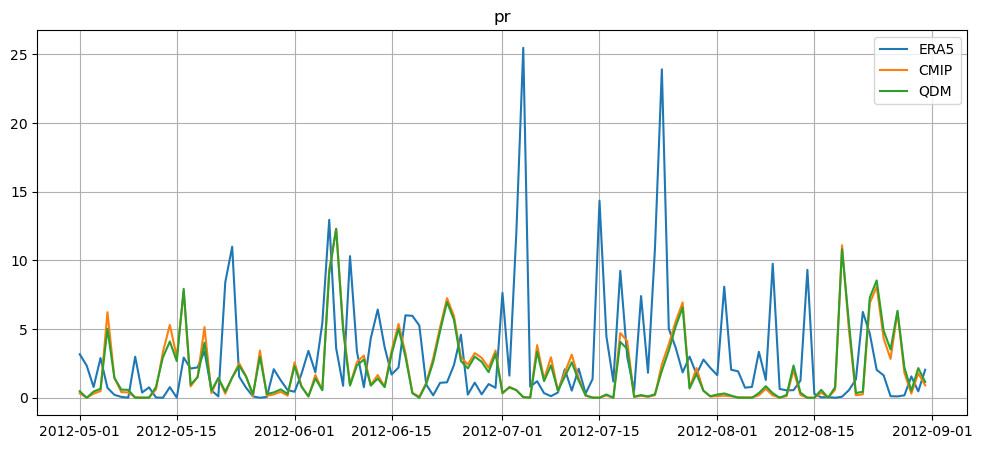

In [126]:
plot_variable_timeseries(
    "pr",
    factor=86400,
    start="2012-05-01",
    end="2012-08-31"
)

In [127]:
def compare_stats(var_name, factor=1):

    era5_da, _, _ = load_variable(forcing_path_ERA5, var_name)
    cmip_da, _, _ = load_variable(forcing_path_CMIP_hist, var_name)
    qdm_da = load_corrected_variable(var_name)

    era5 = to_series(era5_da) * factor
    cmip = to_series(cmip_da) * factor
    qdm = to_series(qdm_da) * factor

    stats = pd.DataFrame({
        "ERA5": era5.describe(),
        "CMIP": cmip.describe(),
        "QDM": qdm.describe()
    })

    return stats

In [128]:
compare_stats("pr", factor=86400)

,ERA5,CMIP,QDM
count,7.305000e+03,7.305000e+03,7305.000000
mean,1.620587e+00,1.723259e+00,1.627803
std,2.418762e+00,2.675928e+00,2.508479
min,-1.665334e-13,1.174351e-13,0.000000
25%,1.879302e-01,1.873050e-01,0.188148
50%,7.593266e-01,7.643056e-01,0.762794
75%,2.028109e+00,2.214770e+00,2.038388
max,2.548246e+01,4.300434e+01,43.004338


In [129]:
def plot_variable_cdf_season(var_name, start_month=5, end_month=10):

    era5_da, _, _ = load_variable(forcing_path_ERA5, var_name)
    cmip_da, _, _ = load_variable(forcing_path_CMIP, var_name)
    qdm_da = load_corrected_variable(var_name)

    era5 = to_series(era5_da)
    cmip = to_series(cmip_da)
    qdm = to_series(qdm_da)

    era5 = era5[era5.index.month.isin(range(start_month, end_month + 1))]
    cmip = cmip[cmip.index.month.isin(range(start_month, end_month + 1))]
    qdm = qdm[qdm.index.month.isin(range(start_month, end_month + 1))]

    if var_name == "tas":
        era5 = era5 - 273.15
        cmip = cmip - 273.15
        qdm = qdm - 273.15
        xlabel = "Temperature (°C)"

    elif var_name in ["pr", "evspsblpot"]:
        era5 = era5 * 86400
        cmip = cmip * 86400
        qdm = qdm * 86400
        xlabel = f"{var_name} (mm/day)"

    elif var_name == "rsds":
        xlabel = "Shortwave radiation (W/m²)"
    else:
        xlabel = var_name

    plt.figure(figsize=(8, 5))

    # for name, data in {"ERA5": era5, "CMIP": cmip, "QDM": qdm}.items():
    for name, data in {"CMIP": cmip, "QDM": qdm, "ERA5": era5}.items():

        values = np.sort(data.dropna().values)
        cdf = np.arange(1, len(values) + 1) / len(values)

        plt.plot(values, cdf, label=name)

    plt.xlabel(xlabel)
    plt.ylabel("Cumulative probability")
    plt.title(f"CDF of {var_name}, months {start_month}-{end_month}")
    plt.grid(True)
    plt.legend()
    plt.show()

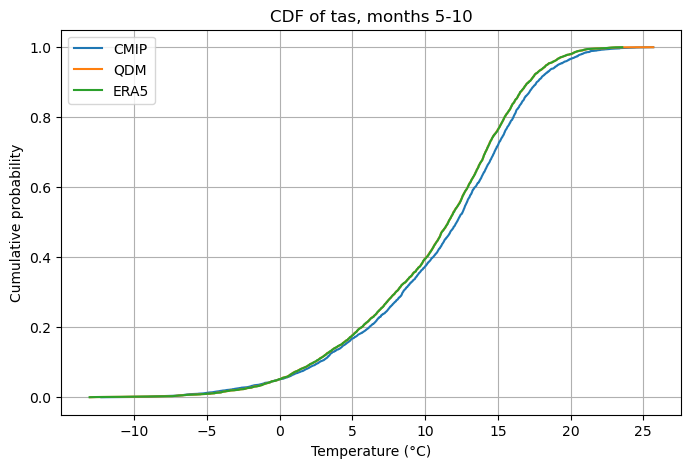

In [130]:
plot_variable_cdf_season("tas", start_month=5, end_month=10)

In [131]:
def forcing_summary_for_year(year):

    variables = ["pr", "tas", "rsds", "evspsblpot"]

    rows = []

    for var_name in variables:

        era5_da, _, _ = load_variable(forcing_path_ERA5, var_name)
        cmip_da, _, _ = load_variable(forcing_path_CMIP_hist, var_name)
        qdm_da = load_corrected_variable(var_name)

        era5 = to_series(era5_da)
        cmip = to_series(cmip_da)
        qdm = to_series(qdm_da)

        # Select year
        era5_y = era5[era5.index.year == year]
        cmip_y = cmip[cmip.index.year == year]
        qdm_y = qdm[qdm.index.year == year]

        # Unit conversion
        if var_name in ["pr", "evspsblpot"]:
            era5_y = era5_y * 86400
            cmip_y = cmip_y * 86400
            qdm_y = qdm_y * 86400
            statistic = "sum mm/year"

            rows.append({
                "variable": var_name,
                "statistic": statistic,
                "ERA5": era5_y.sum(),
                "CMIP": cmip_y.sum(),
                "QDM": qdm_y.sum()
            })

        elif var_name == "tas":
            era5_y = era5_y - 273.15
            cmip_y = cmip_y - 273.15
            qdm_y = qdm_y - 273.15
            statistic = "mean °C"

            rows.append({
                "variable": var_name,
                "statistic": statistic,
                "ERA5": era5_y.mean(),
                "CMIP": cmip_y.mean(),
                "QDM": qdm_y.mean()
            })

        elif var_name == "rsds":
            statistic = "mean W/m²"

            rows.append({
                "variable": var_name,
                "statistic": statistic,
                "ERA5": era5_y.mean(),
                "CMIP": cmip_y.mean(),
                "QDM": qdm_y.mean()
            })

    return pd.DataFrame(rows)

In [177]:
forcing_summary_for_year(2011)

,variable,statistic,ERA5,CMIP,QDM
0,pr,sum mm/year,597.364853,607.485192,583.696337
1,tas,mean °C,1.458792,1.674291,1.379042
2,rsds,mean W/m²,143.142471,138.311142,141.201462
3,evspsblpot,sum mm/year,605.052421,603.664704,603.770733
